In [6]:
import pandas as pd
import numpy as np

In [7]:
data=pd.read_excel("gwl_file.xlsx")

In [8]:
data.head()

,Column13,sin_date,cos_date,cos_month,sin_month,Column3,GWl_dependent,Column10,Column11,Column14,...,South Delhi Municipal Corporation6,South Delhi Municipal Corporation7,South Delhi Municipal Corporation10,South Delhi Municipal Corporation11,South Delhi Municipal Corporation12,Sultan Pur Dabas,Tigi Pur1,Tigi Pur2,Tikri Kalan CT,Ujwa CT
0,0,0.97953,0.201299,0.5,-0.866025,NaN,10.688000,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,0,0.97953,0.201299,0.5,-0.866025,NaN,8.012250,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,0,0.97953,0.201299,0.5,-0.866025,NaN,3.466294,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
3,0,0.97953,0.201299,0.5,-0.866025,NaN,2.613250,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
4,0,0.97953,0.201299,0.5,-0.866025,NaN,1.258500,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


In [9]:
data.shape

(39530, 236)

In [10]:
data.rename(columns={
    "Column13": "year",
    "HISTO_10": "Tree_cover",
    "HISTO_20": "Shrubland",
     "HISTO_30": "Grassland",
     "HISTO_40": "Cropland",
     "HISTO_50": "Built_up",
     "HISTO_60": "sparse_vegetation",
     "HISTO_80": "permenant_water_bodies",
    
}, inplace=True)

In [11]:
data['year'].value_counts()

year
2    21594
1    12508
0     5428
Name: count, dtype: int64

In [12]:
nan_columns = data.columns[data.isnull().all()].tolist()
print(nan_columns)

['Column3', 'Column10', 'Column11', 'Column14', 'Column15', 'Column16', 'Column17', 'Column18', 'Column19', 'Column2', 'Column4', 'Column5', 'Column6', 'Column7', 'Column8', 'Column22', 'Column20', 'Column21', 'Major Parameter Present_QUALITY_2023_2024_2025']


In [13]:
data.drop(nan_columns, axis=1, inplace=True)

In [14]:
print(len(nan_columns))

19


In [15]:
sand_cols = [
    'sand_0-5cm_mean', 'sand_5-15cm_mean', 'sand_15-30cm_mean', 'sand_30-60cm_mean',
    'sand_60-100cm_mean', 'sand_100-200cm_mean', 'silt_0-5cm_mean', 'silt_5-15cm_mean', 
    'silt_15-30cm_mean', 'silt_30-60cm_mean', 'silt_60-100cm_mean', 'silt_100-200cm_mean', 
    'clay_0-5cm_mean', 'clay_5-15cm_mean', 'clay_15-30cm_mean', 'clay_30-60cm_mean', 
    'clay_60-100cm_mean', 'clay_100-200cm_mean', 'ocd_0-5cm_mean', 'ocd_5-15cm_mean', 
    'ocd_15-30cm_mean', 'ocd_30-60cm_mean', 'ocd_60-100cm_mean', 'ocd_100-200cm_mean', 
    'phh2o_0-5cm_mean', 'phh2o_5-15cm_mean', 'phh2o_15-30cm_mean', 'phh2o_30-60cm_mean',
    'phh2o_60-100cm_mean', 'phh2o_100-200cm_mean', 'bdod_0-5cm_mean', 'bdod_5-15cm_mean',
    'bdod_15-30cm_mean', 'bdod_30-60cm_mean', 'bdod_60-100cm_mean', 'bdod_100-200cm_mean',
    'cec_0-5cm_mean', 'cec_5-15cm_mean', 'cec_15-30cm_mean', 'cec_30-60cm_mean', 'cec_60-100cm_mean', 
    'cec_100-200cm_mean', 'cfvo_0-5cm_mean', 'cfvo_5-15cm_mean', 'cfvo_15-30cm_mean', 'cfvo_30-60cm_mean', 
    'cfvo_60-100cm_mean', 'cfvo_100-200cm_mean', 'nitrogen_0-5cm_mean', 'nitrogen_5-15cm_mean', 'nitrogen_15-30cm_mean',
    'nitrogen_30-60cm_mean', 'nitrogen_60-100cm_mean', 'nitrogen_100-200cm_mean', 'soc_0-5cm_mean', 'soc_5-15cm_mean',
    'soc_15-30cm_mean', 'soc_30-60cm_mean', 'soc_60-100cm_mean', 'soc_100-200cm_mean'
]


data[sand_cols] = data[sand_cols].apply(pd.to_numeric, errors='coerce')


data['sand_mean'] = data[sand_cols].mean(axis=1)


In [16]:
len(sand_cols)

60

In [17]:
data.drop(sand_cols, inplace=True, axis=1)

In [18]:
data.shape

(39530, 158)

In [19]:
data_ind = pd.DataFrame()

In [20]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

for col in data.columns:
    col_data = data[[col]]  
    data[col] = imputer.fit_transform(col_data).ravel()

In [21]:
data.isnull().sum()

year              0
sin_date          0
cos_date          0
cos_month         0
sin_month         0
                 ..
Tigi Pur1         0
Tigi Pur2         0
Tikri Kalan CT    0
Ujwa CT           0
sand_mean         0
Length: 158, dtype: int64

In [22]:
df_dep=pd.DataFrame()

In [23]:
data_ind=data.drop(columns=['GWl_dependent'])

In [24]:
df_dep=data[['GWl_dependent']]

In [26]:
location_cols = data_ind.columns[97:156]

In [27]:
data_ind.head()

,year,sin_date,cos_date,cos_month,sin_month,wellDepth,Value_atm_pre,Value_Evp,Value_Rain,Value_Temp,...,South Delhi Municipal Corporation7,South Delhi Municipal Corporation10,South Delhi Municipal Corporation11,South Delhi Municipal Corporation12,Sultan Pur Dabas,Tigi Pur1,Tigi Pur2,Tikri Kalan CT,Ujwa CT,sand_mean
0,0.0,0.97953,0.201299,0.5,-0.866025,40.0,98111.257812,-0.002579,1.818651e-07,300.046265,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,162.152542
1,0.0,0.97953,0.201299,0.5,-0.866025,64.0,98093.382812,-0.002560,1.818651e-07,299.992645,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-32768.000000
2,0.0,0.97953,0.201299,0.5,-0.866025,46.0,98102.007812,-0.002305,1.818651e-07,299.951630,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-32768.000000
3,0.0,0.97953,0.201299,0.5,-0.866025,56.0,98102.007812,-0.002305,1.818651e-07,299.951630,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-32768.000000
4,0.0,0.97953,0.201299,0.5,-0.866025,38.0,98169.679688,-0.002199,1.818651e-07,300.502808,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-32768.000000


In [28]:
data_ind.shape

(39530, 157)

In [29]:
exclude_cols = ['year', 'sin_date', 'cos_date', 'cos_month', 'sin_month']
location_cols = data_ind.columns[97:156]  
all_exclude_cols = list(location_cols) + exclude_cols




In [30]:
data_ind.shape

(39530, 157)

In [31]:
df_corr=data_ind.drop(columns=all_exclude_cols,axis=1)

In [32]:
df_corr

,wellDepth,Value_atm_pre,Value_Evp,Value_Rain,Value_Temp,Value_Sm1,Value_Sm2,Value_Sm3,Value_Sm4,avg_househ,...,soil_mosture,Tree_cover,Shrubland,Grassland,Cropland,Built_up,sparse_vegetation,permenant_water_bodies,_count,sand_mean
0,40.0,98111.257812,-0.002579,1.818651e-07,300.046265,0.200526,0.231513,0.239497,0.231968,1104.0,...,-22001.044793,0.048700,0.004300,0.065868,0.382307,0.471240,0.027533,0.000050,59528.0,162.152542
1,64.0,98093.382812,-0.002560,1.818651e-07,299.992645,0.207535,0.238641,0.224548,0.207994,12961.0,...,-22001.044793,0.082004,0.008732,0.040610,0.369043,0.476277,0.020814,0.002521,226868.0,-32768.000000
2,46.0,98102.007812,-0.002305,1.818651e-07,299.951630,0.119735,0.254651,0.297057,0.300678,4435.0,...,-22001.044793,0.266606,0.010237,0.035770,0.109530,0.549839,0.017545,0.010474,33799.0,-32768.000000
3,56.0,98102.007812,-0.002305,1.818651e-07,299.951630,0.119735,0.254651,0.297057,0.300678,82953.0,...,-22001.044793,0.172510,0.006896,0.031973,0.034667,0.441923,0.018028,0.002509,357173.0,-32768.000000
4,38.0,98169.679688,-0.002199,1.818651e-07,300.502808,0.188054,0.220266,0.223994,0.193126,300.0,...,-22001.044793,0.114849,0.006023,0.003573,0.807845,0.062044,0.001302,0.004364,39182.0,-32768.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39525,38.0,97479.351562,-0.001297,1.732829e-02,299.683197,0.426758,0.421963,0.309996,0.238922,365.0,...,-22001.044793,0.187000,0.016000,0.040000,0.370000,0.410000,0.001000,0.010000,129200.0,169.000000
39526,60.0,97479.351562,-0.001297,1.732829e-02,299.683197,0.426758,0.421963,0.309996,0.238922,3455.0,...,-22001.044793,0.108996,0.039185,0.091853,0.296209,0.445397,0.017770,0.000588,129206.0,-32768.000000
39527,58.0,97513.023438,-0.001273,1.957435e-02,299.833984,0.427101,0.421709,0.319211,0.239996,914.0,...,-22001.044793,0.049207,0.026455,0.008446,0.839651,0.075705,0.000301,0.000236,93178.0,-32768.000000
39528,45.0,97420.773438,-0.001342,1.761833e-02,299.631592,0.422012,0.413623,0.313719,0.254506,138556.0,...,-22001.044793,0.121097,0.000375,0.014117,0.020915,0.828618,0.010583,0.004294,314367.0,-32768.000000


In [33]:
corr_matrix = df_corr.corr().abs()

In [34]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [35]:
threshold = 0.9

high_corr_pairs = [(col, row) for col in upper.columns for row in upper.index if abs(upper.loc[row, col]) > threshold]


In [36]:
print(high_corr_pairs)

[('total_population_count', 'avg_househ'), ('tapwater_u', 'tapwater_t'), ('wells_tube', 'area_irrig'), ('wellDepth.1', 'wellDepth'), ('Rainfall Recharge_2023', 'Recharge Worthy Area (ha)_2023_2024_2025'), ('Rainfall Recharge_2024', 'Recharge Worthy Area (ha)_2023_2024_2025'), ('Rainfall Recharge_2024', 'Rainfall Recharge_2023'), ('Rainfall Recharge_2025', 'Recharge Worthy Area (ha)_2023_2024_2025'), ('Rainfall Recharge_2025', 'Rainfall Recharge_2023'), ('Rainfall Recharge_2025', 'Rainfall Recharge_2024'), ('Ground Water Irrigation_2024', 'Ground Water Irrigation_2023'), ('Ground Water Irrigation_2025', 'Ground Water Irrigation_2023'), ('Ground Water Irrigation_2025', 'Ground Water Irrigation_2024'), ('Tanks and Ponds_2024', 'Tanks and Ponds_2023'), ('Tanks and Ponds_2025', 'Tanks and Ponds_2023'), ('Tanks and Ponds_2025', 'Tanks and Ponds_2024'), ('Water Conservation Structure_2024', 'Water Conservation Structure_2023'), ('Water Conservation Structure_2025', 'Water Conservation Structu

In [37]:
df_reduced=pd.DataFrame()


In [38]:
cols_to_drop = set(col2 for col1, col2 in high_corr_pairs)

df_reduced = data_ind.drop(columns=cols_to_drop)

In [39]:
df_reduced.head()

,year,sin_date,cos_date,cos_month,sin_month,Value_atm_pre,Value_Evp,Value_Rain,Value_Temp,Value_Sm1,...,South Delhi Municipal Corporation7,South Delhi Municipal Corporation10,South Delhi Municipal Corporation11,South Delhi Municipal Corporation12,Sultan Pur Dabas,Tigi Pur1,Tigi Pur2,Tikri Kalan CT,Ujwa CT,sand_mean
0,0.0,0.97953,0.201299,0.5,-0.866025,98111.257812,-0.002579,1.818651e-07,300.046265,0.200526,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,162.152542
1,0.0,0.97953,0.201299,0.5,-0.866025,98093.382812,-0.002560,1.818651e-07,299.992645,0.207535,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-32768.000000
2,0.0,0.97953,0.201299,0.5,-0.866025,98102.007812,-0.002305,1.818651e-07,299.951630,0.119735,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-32768.000000
3,0.0,0.97953,0.201299,0.5,-0.866025,98102.007812,-0.002305,1.818651e-07,299.951630,0.119735,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-32768.000000
4,0.0,0.97953,0.201299,0.5,-0.866025,98169.679688,-0.002199,1.818651e-07,300.502808,0.188054,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-32768.000000


In [40]:
df_final=pd.DataFrame()

In [41]:
df_final=pd.concat([df_reduced,df_dep],axis=1)

In [42]:
df_final.head()

,year,sin_date,cos_date,cos_month,sin_month,Value_atm_pre,Value_Evp,Value_Rain,Value_Temp,Value_Sm1,...,South Delhi Municipal Corporation10,South Delhi Municipal Corporation11,South Delhi Municipal Corporation12,Sultan Pur Dabas,Tigi Pur1,Tigi Pur2,Tikri Kalan CT,Ujwa CT,sand_mean,GWl_dependent
0,0.0,0.97953,0.201299,0.5,-0.866025,98111.257812,-0.002579,1.818651e-07,300.046265,0.200526,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,162.152542,10.688000
1,0.0,0.97953,0.201299,0.5,-0.866025,98093.382812,-0.002560,1.818651e-07,299.992645,0.207535,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-32768.000000,8.012250
2,0.0,0.97953,0.201299,0.5,-0.866025,98102.007812,-0.002305,1.818651e-07,299.951630,0.119735,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-32768.000000,3.466294
3,0.0,0.97953,0.201299,0.5,-0.866025,98102.007812,-0.002305,1.818651e-07,299.951630,0.119735,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-32768.000000,2.613250
4,0.0,0.97953,0.201299,0.5,-0.866025,98169.679688,-0.002199,1.818651e-07,300.502808,0.188054,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-32768.000000,1.258500


In [43]:
X = df_final.drop(columns=['GWl_dependent'])

In [44]:
y=df_final[['GWl_dependent']]

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [47]:
from sklearn.preprocessing import StandardScaler

In [48]:
sd= StandardScaler()

In [49]:
x_train_trf=sd.fit_transform(X_train)
x_test_trf=sd.transform(X_test)

In [50]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *

In [51]:
model=Sequential()

In [52]:
X.shape

(39530, 118)

In [53]:
model.add(Dense(128, activation='relu', input_dim=118))
model.add(BatchNormalization())     
model.add(Dropout(0.2))            


model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(1, activation='linear')) 


C:\Users\Mcc\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          15,232 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41,345 (161.50 KB)

 Trainable params: 40,705 (159.00 KB)

 Non-trainable params: 640 (2.50 KB)

In [55]:
model.compile(optimizer='Adam',loss='mse',metrics=['mae'])

In [56]:
history=model.fit(x_train_trf,y_train,batch_size=64,epochs=100,validation_split=0.2)

Epoch 1/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 38.8022 - mae: 3.9589 - val_loss: 2.0569 - val_mae: 0.9505
Epoch 2/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 13.7728 - mae: 2.6390 - val_loss: 1.5953 - val_mae: 0.8410
Epoch 3/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 11.9688 - mae: 2.4660 - val_loss: 1.2620 - val_mae: 0.6974
Epoch 4/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 11.3674 - mae: 2.4369 - val_loss: 2.8350 - val_mae: 1.0539
Epoch 5/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 10.9770 - mae: 2.4384 - val_loss: 1.0092 - val_mae: 0.6830
Epoch 6/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 9.6776 - mae: 2.3042 - val_loss: 1.0021 - val_mae: 0.6582
Epoch 7/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 9.3993 - mae: 2.2838 - val_loss: 1.1013 - val_mae: 0.6716
Epoch 8/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 9.5577 - mae: 2.3081 - val_loss: 1.2543 - val_mae: 0.6925
Epoch 9/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 3s

In [57]:
import matplotlib.pyplot as plt

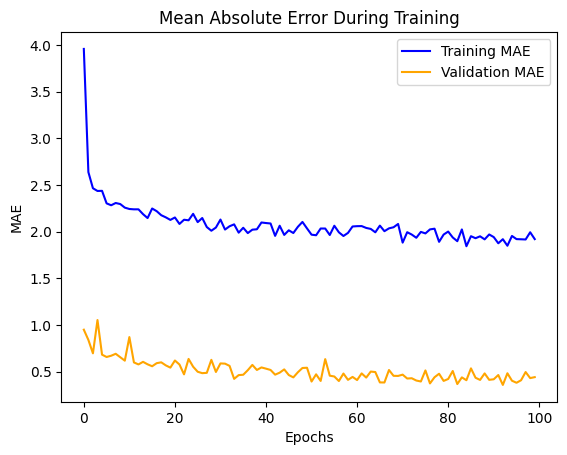

In [58]:
plt.plot(history.history['mae'], color='blue', label='Training MAE')
plt.plot(history.history['val_mae'], color='orange', label='Validation MAE')
plt.title('Mean Absolute Error During Training')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()


In [61]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

In [62]:
model1=Sequential()

In [63]:
model1.add(Dense(128, activation='relu', input_dim=118,kernel_regularizer=l2(1e-4)))
model1.add(BatchNormalization())     
model1.add(Dropout(0.3))            


model1.add(Dense(128, activation='relu',kernel_regularizer=l2(1e-4)))
model1.add(BatchNormalization())
model1.add(Dropout(0.25))

model1.add(Dense(128, activation='tanh',kernel_regularizer=l2(1e-4)))
model1.add(BatchNormalization())
model1.add(Dropout(0.25))

model1.add(Dense(64, activation='tanh',kernel_regularizer=l2(1e-4)))
model1.add(BatchNormalization())
model1.add(Dropout(0.2))

model1.add(Dense(1, activation='linear')) 

C:\Users\Mcc\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 128)                 │          15,232 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 57,473 (224.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [65]:
optimizer = Adam(learning_rate=0.001)
model1.compile(optimizer=optimizer,loss='mse',metrics=['mae'])


In [66]:
history=model1.fit(x_train_trf,y_train,batch_size=64,epochs=100,validation_split=0.2)

Epoch 1/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 55.7746 - mae: 5.1054 - val_loss: 11.4650 - val_mae: 2.3379
Epoch 2/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 20.1841 - mae: 3.4010 - val_loss: 8.9200 - val_mae: 2.1266
Epoch 3/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 17.0977 - mae: 3.1242 - val_loss: 7.6980 - val_mae: 1.9498
Epoch 4/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 14.8109 - mae: 2.9076 - val_loss: 4.5960 - val_mae: 1.3912
Epoch 5/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 14.5454 - mae: 2.8817 - val_loss: 4.4170 - val_mae: 1.3646
Epoch 6/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 13.4243 - mae: 2.7753 - val_loss: 3.5494 - val_mae: 1.2048
Epoch 7/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 13.6026 - mae: 2.8007 - val_loss: 3.4675 - val_mae: 1.2168
Epoch 8/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 12.7313 - mae: 2.7128 - val_loss: 2.7571 - val_mae: 0.9677
Epoch 9/100
346/346 ━━━━━━━━━━━━━

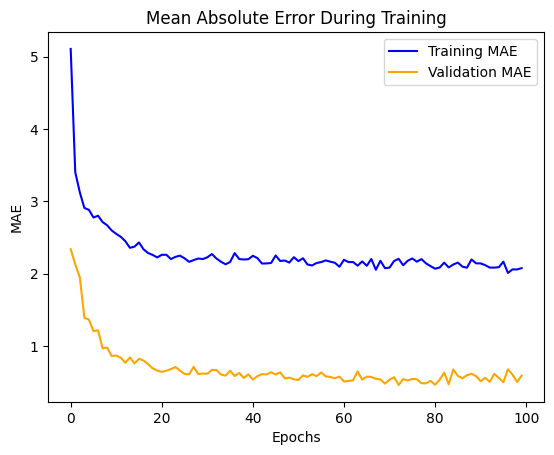

In [67]:
plt.plot(history.history['mae'], color='blue', label='Training MAE')
plt.plot(history.history['val_mae'], color='orange', label='Validation MAE')
plt.title('Mean Absolute Error During Training')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [68]:
loss, mae =model1.evaluate(x_test_trf, y_test)
print("Test Loss:", loss)
print("Test MAE:", mae)

371/371 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.0607 - mae: 0.5973
Test Loss: 1.060672402381897
Test MAE: 0.5973401069641113


In [69]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [70]:
model2=Sequential()

In [71]:



def ann(input_dim=118):
    model2 = Sequential()

    model2.add(Dense(128, activation='relu', input_dim=input_dim, kernel_regularizer=l2(1e-4)))
    model2.add(BatchNormalization())     
    model2.add(Dropout(0.3))            

    model2.add(Dense(128, activation='relu', kernel_regularizer=l2(1e-4)))
    model2.add(BatchNormalization())
    model2.add(Dropout(0.25))

    model2.add(Dense(128, activation='relu', kernel_regularizer=l2(1e-4)))
    model2.add(BatchNormalization())
    model2.add(Dropout(0.25))

    model2.add(Dense(64, activation='relu', kernel_regularizer=l2(1e-4)))
    model2.add(BatchNormalization())
    model2.add(Dropout(0.2))

    model2.add(Dense(1, activation='linear'))  

    model2.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

    return model2


In [84]:
model2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                     │ (None, 128)                 │          15,232 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 173,317 (677.02 KB)

 Trainable params: 57,473 (224.50 KB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 114,948 (449.02 KB)

In [72]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model2.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


In [73]:
batch_sizes = [32, 64, 128]
epoch_options = [200]
results = {}

for batch in batch_sizes:
    for ep in epoch_options:
        print(f"\n Training with batch_size={batch}, epochs={ep}")

        
        model2 = ann(input_dim=118)

        history = model2.fit(
            x_train_trf, y_train,
            validation_split=0.15,
            epochs=ep,
            batch_size=batch,
            callbacks=[early_stop, reduce_lr, checkpoint],
            verbose=1
        )

        best_val_loss = min(history.history['val_loss'])
        stopped_epoch = len(history.history['loss'])

        results[(batch, ep)] = {
            'val_loss': best_val_loss,
            'epochs_ran': stopped_epoch
        }

        print(f"Finished: batch={batch}, epochs={ep}, stopped at {stopped_epoch}, best val_loss={best_val_loss:.4f}")



 Training with batch_size=32, epochs=200


C:\Users\Mcc\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
730/735 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 81.8735 - mae: 6.0772
Epoch 1: val_loss improved from None to 2.31204, saving model to best_model2.h5


735/735 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 42.8033 - mae: 4.4744 - val_loss: 2.3120 - val_mae: 1.0110 - learning_rate: 0.0010
Epoch 2/200
727/735 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.4449 - mae: 3.4904
Epoch 2: val_loss did not improve from 2.31204
735/735 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 21.3076 - mae: 3.4241 - val_loss: 2.3208 - val_mae: 0.9807 - learning_rate: 0.0010
Epoch 3/200
734/735 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 18.1360 - mae: 3.2045
Epoch 3: val_loss did not improve from 2.31204
735/735 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 17.5369 - mae: 3.1551 - val_loss: 2.4774 - val_mae: 1.0060 - learning_rate: 0.0010
Epoch 4/200
735/735 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15.0918 - mae: 2.9159
Epoch 4: val_loss improved from 2.31204 to 1.61382, saving model to best_model2.h5


735/735 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 16.1882 - mae: 3.0492 - val_loss: 1.6138 - val_mae: 0.8449 - learning_rate: 0.0010
Epoch 5/200
735/735 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.5564 - mae: 2.8793
Epoch 5: val_loss did not improve from 1.61382
735/735 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 14.6090 - mae: 2.8881 - val_loss: 1.9580 - val_mae: 0.8643 - learning_rate: 0.0010
Epoch 6/200
733/735 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.0939 - mae: 2.8413
Epoch 6: val_loss did not improve from 1.61382
735/735 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 14.1943 - mae: 2.8453 - val_loss: 1.8325 - val_mae: 0.9017 - learning_rate: 0.0010
Epoch 7/200
733/735 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.2887 - mae: 2.8817
Epoch 7: val_loss improved from 1.61382 to 1.20736, saving model to best_model2.h5


...

Epoch 1/200
365/368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 94.4784 - mae: 6.4180
Epoch 1: val_loss did not improve from 1.20736
368/368 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 45.9758 - mae: 4.4131 - val_loss: 3.1127 - val_mae: 1.0943 - learning_rate: 0.0010
Epoch 2/200
367/368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 17.0214 - mae: 2.9235
Epoch 2: val_loss did not improve from 1.20736
368/368 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 16.1833 - mae: 2.8425 - val_loss: 2.2925 - val_mae: 0.9763 - learning_rate: 0.0010
Epoch 3/200
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 14.9698 - mae: 2.6751
Epoch 3: val_loss did not improve from 1.20736
368/368 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 14.4745 - mae: 2.6530 - val_loss: 2.3934 - val_mae: 0.9637 - learning_rate: 0.0010
Epoch 4/200
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 14.1026 - mae: 2.6226
Epoch 4: val_loss did not improve from 1.20736
368/368 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 13.9747 - mae: 2.6061 - val_loss:

368/368 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 9.8969 - mae: 2.3268 - val_loss: 1.1658 - val_mae: 0.6962 - learning_rate: 0.0010
Epoch 10/200
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.0357 - mae: 2.2451
Epoch 10: val_loss did not improve from 1.16584
368/368 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 9.2146 - mae: 2.2662 - val_loss: 1.2025 - val_mae: 0.7399 - learning_rate: 0.0010
Epoch 11/200
365/368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.1926 - mae: 2.2673
Epoch 11: val_loss improved from 1.16584 to 0.91864, saving model to best_model2.h5


368/368 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 9.6197 - mae: 2.3248 - val_loss: 0.9186 - val_mae: 0.6180 - learning_rate: 0.0010
Epoch 12/200
366/368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.1104 - mae: 2.2584
Epoch 12: val_loss did not improve from 0.91864
368/368 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 8.9183 - mae: 2.2318 - val_loss: 1.2604 - val_mae: 0.6891 - learning_rate: 0.0010
Epoch 13/200
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.3479 - mae: 2.1617
Epoch 13: val_loss did not improve from 0.91864
368/368 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 8.5067 - mae: 2.1887 - val_loss: 0.9433 - val_mae: 0.5981 - learning_rate: 0.0010
Epoch 14/200
365/368 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.3896 - mae: 2.2937
Epoch 14: val_loss did not improve from 0.91864
368/368 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 9.5486 - mae: 2.3166 - val_loss: 1.2588 - val_mae: 0.7103 - learning_rate: 0.0010
Epoch 15/200
364/368 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.9666 - mae: 2.1082


C:\Users\Mcc\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
181/184 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 110.5943 - mae: 7.0173
Epoch 1: val_loss did not improve from 0.91864
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 54.6092 - mae: 4.7471 - val_loss: 4.8856 - val_mae: 1.5881 - learning_rate: 0.0010
Epoch 2/200
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 15.0157 - mae: 2.7657
Epoch 2: val_loss did not improve from 0.91864
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 14.1540 - mae: 2.6564 - val_loss: 3.5773 - val_mae: 1.2671 - learning_rate: 0.0010
Epoch 3/200
179/184 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13.1158 - mae: 2.5081
Epoch 3: val_loss did not improve from 0.91864
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 12.2009 - mae: 2.4056 - val_loss: 2.2835 - val_mae: 0.9617 - learning_rate: 0.0010
Epoch 4/200
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 11.4594 - mae: 2.3433
Epoch 4: val_loss did not improve from 0.91864
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 11.1609 - mae: 2.3045 - val

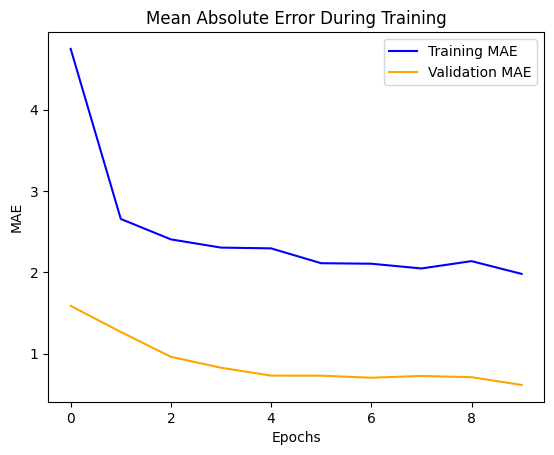

In [74]:
plt.plot(history.history['mae'], color='blue', label='Training MAE')
plt.plot(history.history['val_mae'], color='orange', label='Validation MAE')
plt.title('Mean Absolute Error During Training')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [75]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np




In [76]:
y_pred = model2.predict(x_test_trf)


mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

371/371 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
MSE: 4.9362
MAE: 1.5974
RMSE: 2.2218
R² Score: 0.9784


In [77]:
from sklearn.inspection import permutation_importance

In [79]:
!pip install scikeras



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [81]:
from scikeras.wrappers import KerasRegressor

from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

def permutation_importance_keras(model2, X, y, metric=r2_score):
    baseline = metric(y, model2.predict(X))
    importances = {}
    X_copy = X.copy()

    for col in X.columns:
        shuffled = X_copy.copy()
        shuffled[col] = np.random.permutation(shuffled[col])
        score = metric(y, model2.predict(shuffled))
        importances[col] = baseline - score

    return pd.Series(importances).sort_values(ascending=False)

importance = permutation_importance_keras(model, X_test, y_test)
print(importance)



371/371 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
371/371 ━━━━━━━━